In [6]:
## IMPORTS AND SETUP
# Jupyter Notebook setup
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.insert(0, "/tf/projet") # Add the project root directory to the Python path (docker hosting)


import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from Leyanda_Project.utils.warning_clean import silence_tensorflow_warnings
from Leyanda_Project.preprocessing.noise import load_clear_images, normalize_image, visualize_data
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras import backend as K

# Suppress warnings
silence_tensorflow_warnings()

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU is available: {len(gpus)} device(s) detected")
    except RuntimeError as e:
        print("Error configuring GPU:", str(e))
else:
    print("No GPU available, using CPU")

# Wandb setup
if not os.path.exists("/tf/projet/.env"):
    print("WARNING: No .env file found, please create one with your Wandb API key.")
    exit(1)
else:
    load_dotenv("/tf/projet/.env")
    WANDB_API_KEY = os.getenv("API_KEY")
    wandb_entity = "tom-antoine-cesi"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
TensorFlow warnings suppression is active.
GPU is available: 1 device(s) detected


In [7]:
## PARAMETERS
raw_data_path = "/tf/projet/Dataset_livrable_2" # Path to the raw data folder
img_height = 180 # Image height for dataset loading
img_width = 180 # Image width for dataset loading
batch_size = 16 # Batch size for dataset loading
save_model_denoise_filename = "denoiser.h5" # Model save filename
n = 10 # Number of images displayed for visualization

# Dataset split parameters
train_split = 0.9 # Proportion of the dataset to use for training
test_split = 0.1 # Proportion of the dataset to use for testing

# Noise parameters
noise_factor = 0.2 # Percentage of noise added into the images
nb_epoch_denoise = 300 # Number of epochs ran by the denoising model

--Checking directory: /tf/projet/Dataset_livrable_2--
Directory /tf/projet/Dataset_livrable_2 exists

--Loading images from /tf/projet/Dataset_livrable_2--

--Normalizing images--


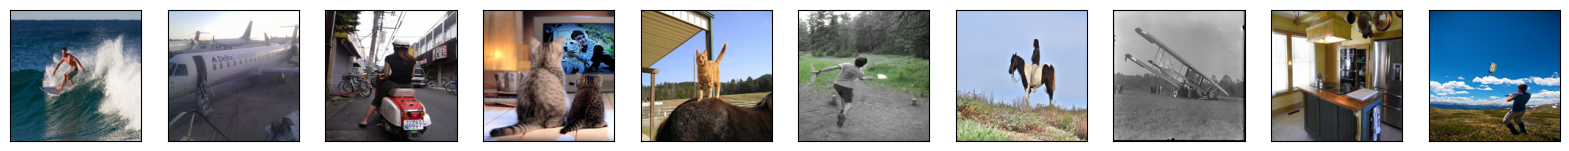

In [8]:
## DATA PREPARATION WORKFLOW
# 1. Check dataset existence
print(f"--Checking directory: {raw_data_path}--")
if not os.path.isdir(raw_data_path):
    print(f"Directory {raw_data_path} doesn't exist")
    exit(1)
else:
    print(f"Directory {raw_data_path} exists")

# 2. Load dataset
images_train, images_test = load_clear_images(
    raw_data_path=raw_data_path,
    img_height=img_height,
    img_width=img_width,
    test_split=test_split
)

# 3. Normalize dataset
x_train, x_test = normalize_image(images_train=images_train, images_test=images_test)

# 4. Visualize
visualize_data(X=x_train, n=n)

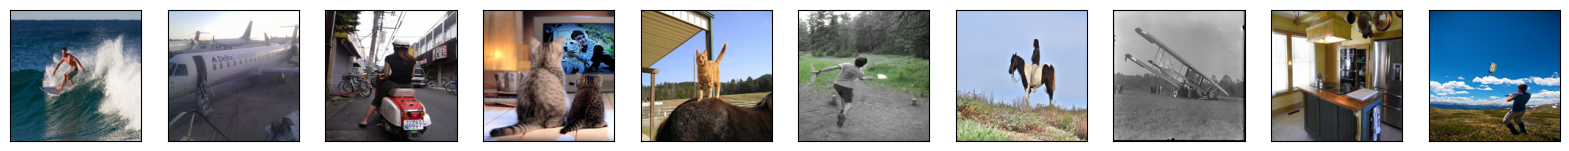

In [81]:

def display_image(X, n):
    plt.figure(figsize=(20, 2))
    for i in range(n):
        ax = plt.subplot(1, n, i + 1)
        plt.imshow(X[i])
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
    plt.show()

display_image(x_train, n=10)

In [82]:
# create train_noisy and test_noisy
def add_noise(images, noise_factor = 0.2):
    noisy_images = images + noise_factor * np.random.normal(loc=0.0, scale=1., size=images.shape)
    noisy_images = np.clip(noisy_images, 0., 1.)
    return noisy_images

x_train_noisy = add_noise(x_train, noise_factor)
x_test_noisy = add_noise(x_test, noise_factor)

Visualisez les images d'origines puis les images bruitées.

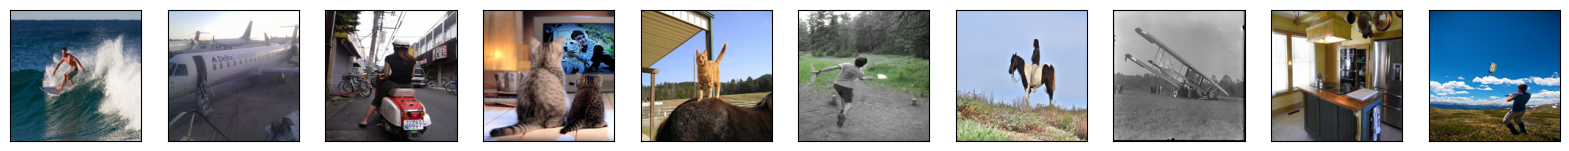

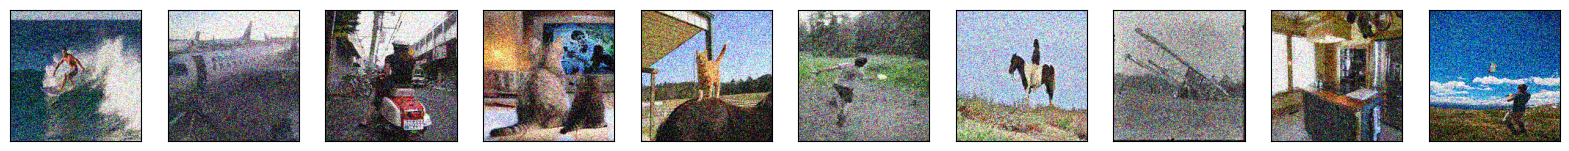

In [83]:
display_image(x_train, n=10)
display_image(x_train_noisy, n=10)

In [84]:
# The encoding process
input_img = Input(shape=(IMG_SIZE, IMG_SIZE, 3)) # input image dimensions

# Encoding #
x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)

# Decoding #
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)

decoded = Conv2D(3, (3, 3), activation= 'relu', padding='same')(x)



In [85]:
# Declare the model
autoencoder = Model(inputs=input_img, outputs=decoded)
autoencoder.compile(optimizer='adam', loss="mae", metrics=['accuracy'])
autoencoder.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_37 (InputLayer)     │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 180, 180, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 180, 180, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 180, 180, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 180, 180, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 180, 180, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 180, 180, 3)    │           435 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,035 (328.26 KB)

 Trainable params: 84,035 (328.26 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [87]:
# Train the model
history = None

history = autoencoder.fit(x_train_noisy, x_train,
                epochs=NB_EPOCHS_DENOISE,
                batch_size=BATCH_SIZE,
                shuffle=True,
                validation_data=(x_test_noisy, x_test),
                verbose=1)

Epoch 1/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 229ms/step - accuracy: 0.3661 - loss: 0.3464 - val_accuracy: 0.4667 - val_loss: 0.1773
Epoch 2/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.4831 - loss: 0.1389 - val_accuracy: 0.3976 - val_loss: 0.1096
Epoch 3/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.4235 - loss: 0.0937 - val_accuracy: 0.3998 - val_loss: 0.0958
Epoch 4/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.3432 - loss: 0.0854 - val_accuracy: 0.5114 - val_loss: 0.0908
Epoch 5/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.4258 - loss: 0.0810 - val_accuracy: 0.4986 - val_loss: 0.0829
Epoch 6/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.4582 - loss: 0.0727 - val_accuracy: 0.5569 - val_loss: 0.0821
Epoch 7/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.5448 - loss: 0.0734 - val_accuracy: 0.6276 - val_loss: 0.0680
Epoch 8/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.6129 - loss: 0.0625 - val_accuracy: 0.6428 - val_loss

Affichez maintenant la courbe d'apprentissage. Que pensez-vous des performances du modèle ?

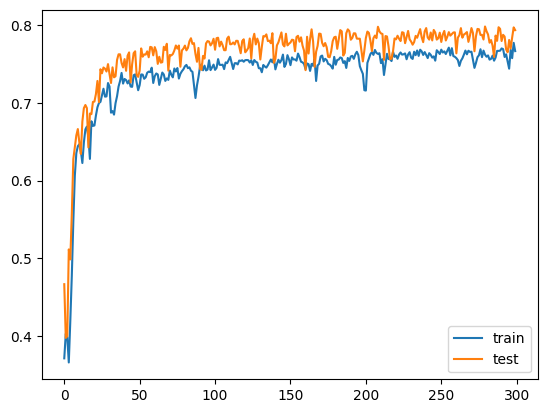

In [88]:
# Visualisation des pertes d'apprentissage (Train) et de validation (Test)
plt.plot(history.history['accuracy'],
         label='train')
plt.plot(history.history['val_accuracy'],
         label='test')
plt.legend()

In [89]:
# save the model
autoencoder.save(SAV_MODEL_DENOISE)

decoded_imgs = autoencoder.predict(x_test_noisy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step


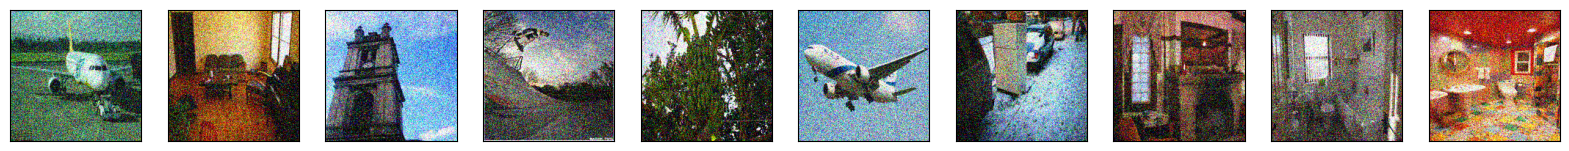

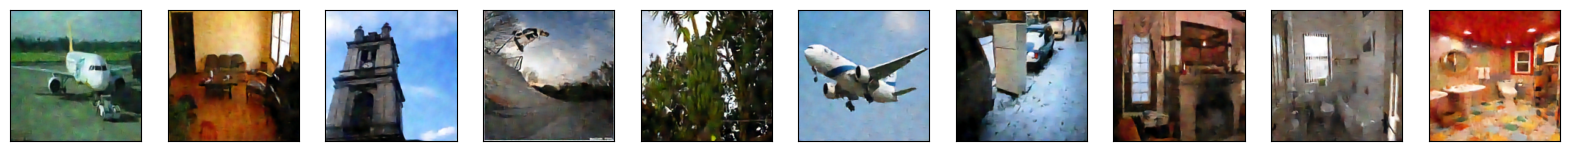

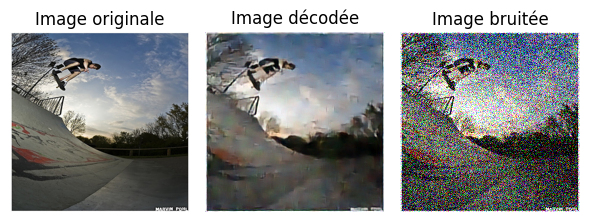

In [91]:
display_image(x_test_noisy, n=10)
display_image(decoded_imgs, n=10)

fig, axes = plt.subplots(1, 3, figsize=(6, 3))
axes[0].imshow(x_test[3].squeeze(), vmin=0, vmax=1)
axes[0].set_title("Image originale")
axes[0].axis("off")
axes[1].imshow(decoded_imgs[3].squeeze(), vmin=0, vmax=1)
axes[1].set_title("Image décodée")
axes[1].axis("off")
axes[2].imshow(x_test_noisy[3].squeeze(), vmin=0, vmax=1)
axes[2].set_title("Image bruitée")
axes[2].axis("off")
plt.tight_layout()
plt.show()



